In [4]:
import pandas as pd
import numpy as np

df = pd.read_excel("retail_sales_dataset_final.xlsx")
df

FileNotFoundError: [Errno 2] No such file or directory: 'retail_sales_dataset_final.xlsx'

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1000 non-null   datetime64[ns]
 1   Customer_ID  1000 non-null   int64         
 2   Product      1000 non-null   object        
 3   Category     1000 non-null   object        
 4   Quantity     1000 non-null   int64         
 5   Price        1000 non-null   int64         
 6   Sales        1000 non-null   int64         
 7   Gender       1000 non-null   object        
 8   Age          1000 non-null   int64         
 9   Year         1000 non-null   int64         
 10  Month_Name   1000 non-null   object        
 11  Region       1000 non-null   object        
dtypes: datetime64[ns](1), int64(6), object(5)
memory usage: 93.9+ KB


In [4]:
df.describe()

,Customer_ID,Quantity,Price,Sales,Age,Year
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,1049.128000,3.050000,23800.284000,72286.52200,41.204000,2023.50000
std,29.573505,1.424616,14236.925293,57670.18043,13.416721,0.50025
min,1000.000000,1.000000,597.000000,641.00000,18.000000,2023.00000
25%,1023.000000,2.000000,11570.250000,26191.25000,30.000000,2023.00000
50%,1050.000000,3.000000,22690.000000,57370.00000,41.000000,2023.50000
75%,1074.000000,4.000000,35306.750000,104827.50000,53.000000,2024.00000
max,1099.000000,5.000000,49937.000000,248295.00000,64.000000,2024.00000


In [5]:
df.shape

(1000, 12)

In [6]:
df.isnull().sum()


Date           0
Customer_ID    0
Product        0
Category       0
Quantity       0
Price          0
Sales          0
Gender         0
Age            0
Year           0
Month_Name     0
Region         0
dtype: int64

In [7]:
df.duplicated().sum()


0

In [3]:
df[df["Sales"] <= 0]


,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region


In [5]:
# Define correct month order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Group and reorder
monthly_sales = (
    df.groupby("Month_Name")["Sales"]
      .sum()
      .reindex(month_order)
)

# Plot
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


NameError: name 'plt' is not defined

In [4]:
monthly_sales

NameError: name 'monthly_sales' is not defined

In [16]:
df

,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region
0,2023-01-01,1051,Mobile,Electronics,3,38828,116484,Male,24,2023,January,East
1,2023-01-01,1092,Bag,Accessories,3,16392,49176,Male,60,2023,January,West
2,2023-01-02,1014,Laptop,Electronics,3,47799,143397,Male,41,2023,January,West
3,2023-01-03,1071,Shoes,Fashion,1,17573,17573,Female,21,2023,January,Central
4,2023-01-03,1060,Headphones,Electronics,4,37268,149072,Male,45,2023,January,South
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-12-28,1009,Mobile,Electronics,3,21308,63924,Male,54,2024,December,West
996,2024-12-28,1066,Bag,Accessories,4,30654,122616,Male,32,2024,December,South
997,2024-12-29,1017,Watch,Accessories,2,35273,70546,Female,64,2024,December,South
998,2024-12-30,1099,Shoes,Fashion,2,28247,56494,Female,21,2024,December,South


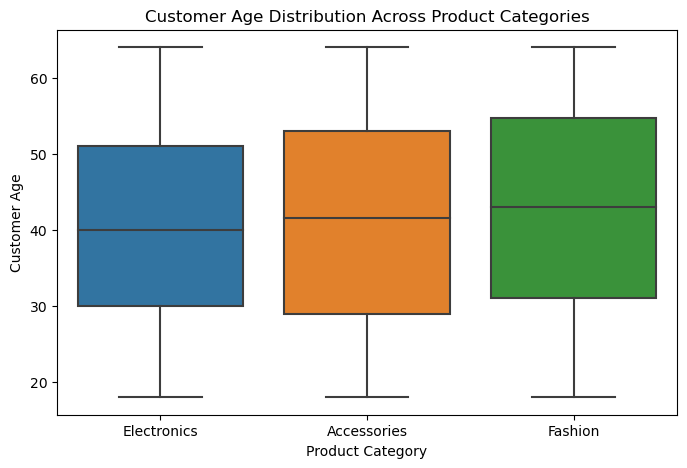

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Age", data=df)

plt.title("Customer Age Distribution Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Customer Age")

plt.show()


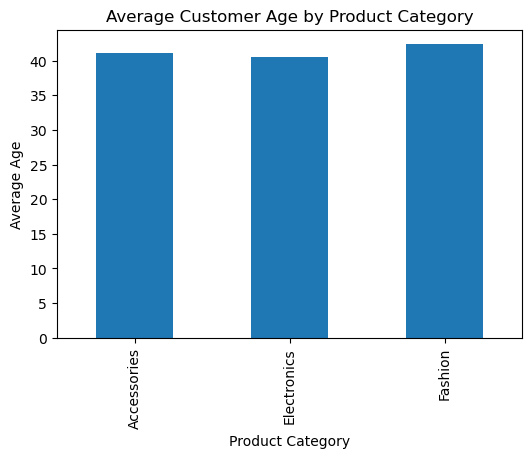

In [18]:
avg_age_category = df.groupby("Category")["Age"].mean()

plt.figure(figsize=(6,4))
avg_age_category.plot(kind="bar")

plt.title("Average Customer Age by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Age")

plt.show()


In [18]:
df["Customer_Type"] = np.random.choice(["New", "Returning"], size=len(df))


In [19]:
df

,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region,Age_Group,Customer_Type
0,2023-01-01,1051,Mobile,Electronics,3,38828,116484,Male,24,2023,January,East,18–25,Returning
1,2023-01-01,1092,Bag,Accessories,3,16392,49176,Male,60,2023,January,West,46–60,Returning
2,2023-01-02,1014,Laptop,Electronics,3,47799,143397,Male,41,2023,January,West,36–45,New
3,2023-01-03,1071,Shoes,Fashion,1,17573,17573,Female,21,2023,January,Central,18–25,New
4,2023-01-03,1060,Headphones,Electronics,4,37268,149072,Male,45,2023,January,South,36–45,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2024-12-28,1009,Mobile,Electronics,3,21308,63924,Male,54,2024,December,West,46–60,New
996,2024-12-28,1066,Bag,Accessories,4,30654,122616,Male,32,2024,December,South,26–35,Returning
997,2024-12-29,1017,Watch,Accessories,2,35273,70546,Female,64,2024,December,South,60+,New
998,2024-12-30,1099,Shoes,Fashion,2,28247,56494,Female,21,2024,December,South,18–25,New


In [21]:
payment_methods = ["Cash", "Credit Card", "Debit Card", "UPI"]
df["Payment_Method"] = np.random.choice(payment_methods, size=len(df))


In [22]:
df["Sales_Channel"] = np.random.choice(["Online", "Offline"], size=len(df))


In [3]:
df

NameError: name 'df' is not defined

In [3]:
pd.to_csv("Final_data.csv")

AttributeError: module 'pandas' has no attribute 'to_csv'

In [13]:
# Create age groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 60, 100],
    labels=["18–25", "26–35", "36–45", "46–60", "60+"]
)


In [14]:
# Count unique customers per age group
age_group_counts = (
    df.drop_duplicates(subset="Customer_ID")
      .groupby("Age_Group")
      .size()
)


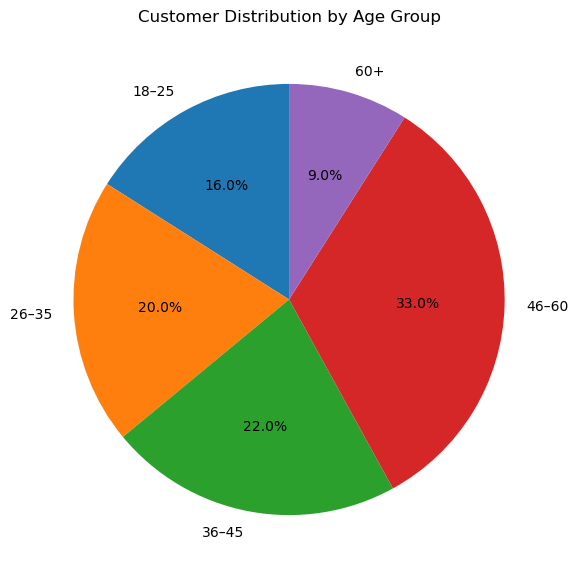

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.pie(
    age_group_counts,
    labels=age_group_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Age Group")
plt.show()


In [1]:
df.to_csv("Reatil_data_final.csv", index=False)

NameError: name 'df' is not defined

In [5]:
import numpy as np

# Generate random cost price between 60% to 80% of price
df["Cost_Price"] = df["Price"] * np.random.uniform(0.6, 0.8, size=len(df))



NameError: name 'df' is not defined

In [6]:
import pandas as pd

df = pd.read_csv("Reatil_data_final.csv")  # use the exact filename shown on the left
df.head()


,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region,Age_Group,Customer_Type,Payment_Method,Sales_Channel
0,01-01-2023,1051,Mobile,Electronics,3,38828,116484,Male,24,2023,January,East,18-25,Returning,Debit Card,Online
1,01-01-2023,1092,Bag,Accessories,3,16392,49176,Male,60,2023,January,West,46-60,Returning,Debit Card,Online
2,02-01-2023,1014,Laptop,Electronics,3,47799,143397,Male,41,2023,January,West,36-45,New,UPI,Offline
3,03-01-2023,1071,Shoes,Fashion,1,17573,17573,Female,21,2023,January,Central,18-25,New,Credit Card,Offline
4,03-01-2023,1060,Headphones,Electronics,4,37268,149072,Male,45,2023,January,South,36-45,New,Cash,Offline


In [7]:
import numpy as np

df["Cost_Price"] = df["Price"] * np.random.uniform(0.6, 0.8, size=len(df))


In [8]:
df["Profit"] = (df["Price"] - df["Cost_Price"]) * df["Quantity"]


In [9]:
df.to_csv("Retail_data_final_updated.csv", index=False)


In [10]:
df.head()

,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region,Age_Group,Customer_Type,Payment_Method,Sales_Channel,Cost_Price,Profit
0,01-01-2023,1051,Mobile,Electronics,3,38828,116484,Male,24,2023,January,East,18-25,Returning,Debit Card,Online,23723.959626,45312.121123
1,01-01-2023,1092,Bag,Accessories,3,16392,49176,Male,60,2023,January,West,46-60,Returning,Debit Card,Online,12012.183316,13139.450052
2,02-01-2023,1014,Laptop,Electronics,3,47799,143397,Male,41,2023,January,West,36-45,New,UPI,Offline,29047.032299,56255.903104
3,03-01-2023,1071,Shoes,Fashion,1,17573,17573,Female,21,2023,January,Central,18-25,New,Credit Card,Offline,11407.976110,6165.023890
4,03-01-2023,1060,Headphones,Electronics,4,37268,149072,Male,45,2023,January,South,36-45,New,Cash,Offline,28897.742167,33481.031332


In [11]:
df["Cost_Price"] = df["Cost_Price"].round(2)
df["Profit"] = df["Profit"].round(2)


In [12]:
df.head()

,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region,Age_Group,Customer_Type,Payment_Method,Sales_Channel,Cost_Price,Profit
0,01-01-2023,1051,Mobile,Electronics,3,38828,116484,Male,24,2023,January,East,18-25,Returning,Debit Card,Online,23723.96,45312.12
1,01-01-2023,1092,Bag,Accessories,3,16392,49176,Male,60,2023,January,West,46-60,Returning,Debit Card,Online,12012.18,13139.45
2,02-01-2023,1014,Laptop,Electronics,3,47799,143397,Male,41,2023,January,West,36-45,New,UPI,Offline,29047.03,56255.90
3,03-01-2023,1071,Shoes,Fashion,1,17573,17573,Female,21,2023,January,Central,18-25,New,Credit Card,Offline,11407.98,6165.02
4,03-01-2023,1060,Headphones,Electronics,4,37268,149072,Male,45,2023,January,South,36-45,New,Cash,Offline,28897.74,33481.03


In [13]:
df.tail()

,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region,Age_Group,Customer_Type,Payment_Method,Sales_Channel,Cost_Price,Profit
995,28-12-2024,1009,Mobile,Electronics,3,21308,63924,Male,54,2024,December,West,46-60,New,Credit Card,Offline,15539.31,17306.08
996,28-12-2024,1066,Bag,Accessories,4,30654,122616,Male,32,2024,December,South,26-35,Returning,Debit Card,Offline,19259.51,45577.95
997,29-12-2024,1017,Watch,Accessories,2,35273,70546,Female,64,2024,December,South,60+,New,Debit Card,Offline,21640.01,27265.98
998,30-12-2024,1099,Shoes,Fashion,2,28247,56494,Female,21,2024,December,South,18-25,New,Cash,Online,20499.39,15495.23
999,31-12-2024,1085,Watch,Accessories,3,11360,34080,Female,57,2024,December,East,46-60,Returning,Credit Card,Offline,7195.88,12492.37


In [2]:
df.to_csv("Retail_data_final.csv", index=False)

NameError: name 'df' is not defined

In [1]:
monthly_sales = monthly_sales.rename(columns={
    'Order Date': 'ds',
    'Revenue': 'y'
})

NameError: name 'monthly_sales' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Retail_data_final.csv")
df.head()

,Date,Customer_ID,Product,Category,Quantity,Price,Sales,Gender,Age,Year,Month_Name,Region,Age_Group,Customer_Type,Payment_Method,Sales_Channel,Cost_Price,Profit
0,01-01-2023,1051,Mobile,Electronics,3,38828,116484,Male,24,2023,January,East,18-25,Returning,Debit Card,Online,23723.96,45312.12
1,01-01-2023,1092,Bag,Accessories,3,16392,49176,Male,60,2023,January,West,46-60,Returning,Debit Card,Online,12012.18,13139.45
2,02-01-2023,1014,Laptop,Electronics,3,47799,143397,Male,41,2023,January,West,36-45,New,UPI,Offline,29047.03,56255.90
3,03-01-2023,1071,Shoes,Fashion,1,17573,17573,Female,21,2023,January,Central,18-25,New,Credit Card,Offline,11407.98,6165.02
4,03-01-2023,1060,Headphones,Electronics,4,37268,149072,Male,45,2023,January,South,36-45,New,Cash,Offline,28897.74,33481.03


In [5]:
monthly_sales.head()


NameError: name 'monthly_sales' is not defined

In [6]:
prophet_data = monthly_sales[['Order Date','Revenue']].copy()

NameError: name 'monthly_sales' is not defined